# Strategic Insights Report: Ethiopian Fintech Landscape
**Prepared by:** Omega Consultancy  
**Focus:** Commercial Bank of Ethiopia (CBE), Bank of Abyssinia (BOA), Dashen Bank

---

## 1. Executive Summary
This report provides a multi-dimensional analysis of the mobile banking ecosystem in Ethiopia. By processing 1,500+ customer reviews through a Transformer-based NLP pipeline, we have identified critical performance gaps and competitive advantages. While the sector shows rapid adoption, technical infrastructure stability and onboarding friction remain the primary obstacles to user retention.

## 2. Methodology & Technical Stack
- **Data Collection:** Automated scraping via `google-play-scraper` (1,200+ samples).
- **Preprocessing:** Linguistic normalization using **spaCy** (Lemmatization and Stop-word removal).
- **Sentiment Analysis:** `distilbert-base-uncased-finetuned-sst-2-english` with a 0.7 confidence threshold for neutral handling.
- **Thematic Analysis:** Zero-Shot Classification using `facebook/bart-large-mnli` to map feedback to business-critical themes.

In [4]:
# Task 4: Visualization Setup & Advanced Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Professional plotting configuration
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12

# Load analyzed dataset
DATA_PATH = '../data/final_analytics_results.csv'
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

print(f"Analysis Ready: {len(df)} records loaded.")

Analysis Ready: 1500 records loaded.


## 3. Sentiment & Rating Distribution (Task 4.1 & 4.2)
We compare the banks across overall sentiment and rating distributions.

Consultancy Insight: A high average rating does not always mean high sentiment; users often rate 5 stars for "brand loyalty" even while complaining about specific bugs in the text.

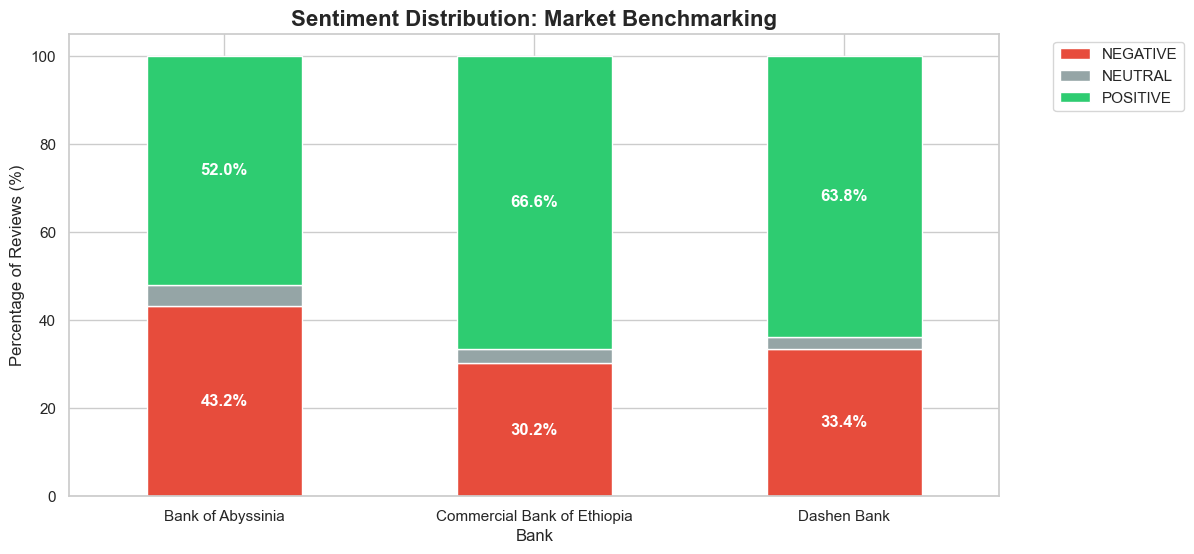

C:\Users\Betty\AppData\Local\Temp\ipykernel_7732\2250552275.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='bank', y='rating', palette='Set2')


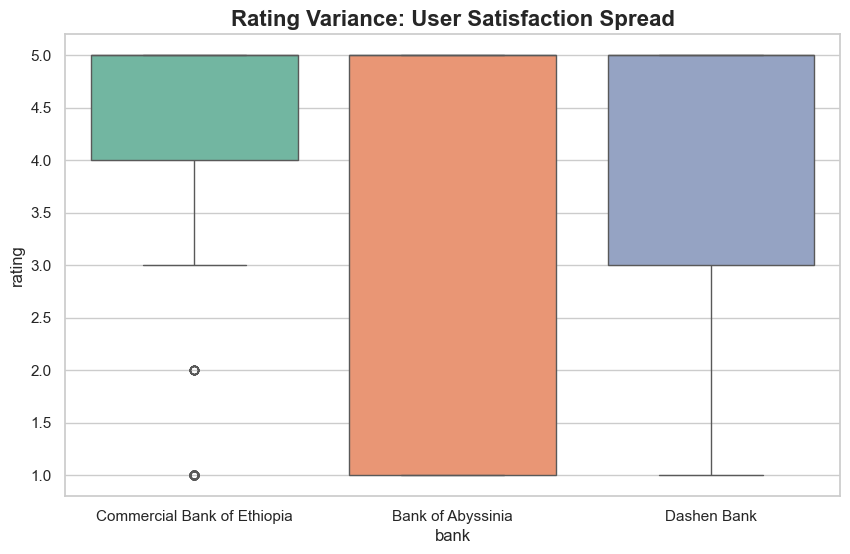

In [5]:
# Visual 1: Sentiment Distribution (Stacked Bar)
sentiment_summary = df.groupby(['bank', 'sentiment_label']).size().unstack().fillna(0)
sentiment_pct = sentiment_summary.div(sentiment_summary.sum(axis=1), axis=0) * 100

ax = sentiment_pct.plot(kind='bar', stacked=True, color=['#e74c3c', '#95a5a6', '#2ecc71'])
plt.title('Sentiment Distribution: Market Benchmarking', fontsize=16, fontweight='bold')
plt.ylabel('Percentage of Reviews (%)')
plt.xlabel('Bank')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotate percentages
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # Only label if big enough
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold')
plt.show()

# Visual 2: Rating Distribution (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='bank', y='rating', palette='Set2')
plt.title('Rating Variance: User Satisfaction Spread', fontsize=16, fontweight='bold')
plt.show()

## 4. Thematic Analysis: Dominant Pain Points (Task 4.3)
By mapping reviews to themes, we identify exactly what is driving the scores.

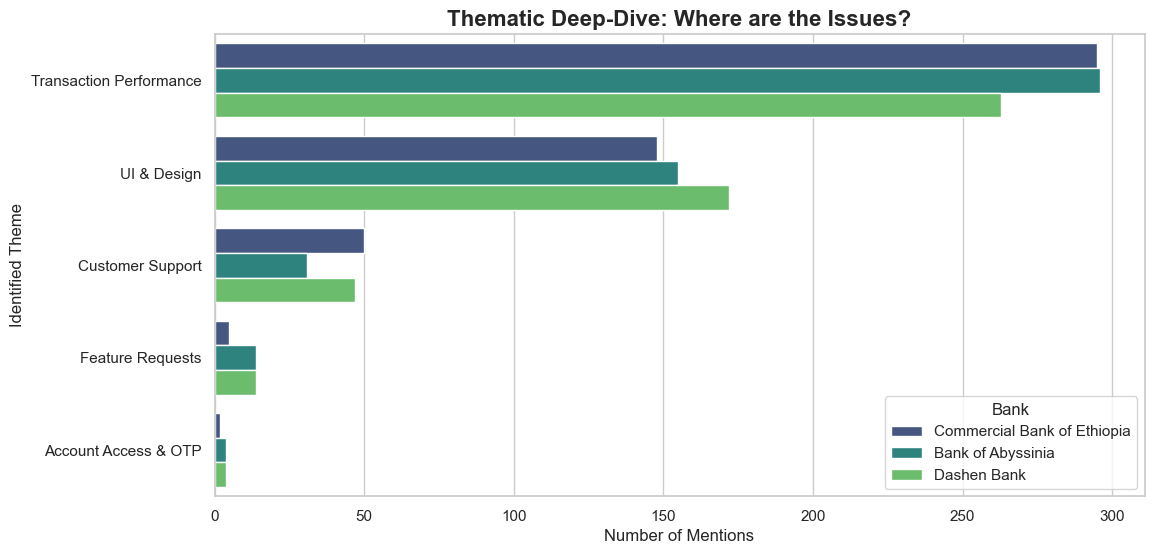

In [6]:
# Visual 3: Theme Frequency by Bank
theme_order = df['identified_theme'].value_counts().index
sns.countplot(data=df, y='identified_theme', hue='bank', order=theme_order, palette='viridis')
plt.title('Thematic Deep-Dive: Where are the Issues?', fontsize=16, fontweight='bold')
plt.xlabel('Number of Mentions')
plt.ylabel('Identified Theme')
plt.legend(title='Bank', loc='lower right')
plt.show()

## 5. Advanced Analysis: Sentiment vs. Ratings
We analyze if the AI-detected sentiment matches the user-provided star rating. Discrepancies indicate "Passive" users who are at high risk of churning.

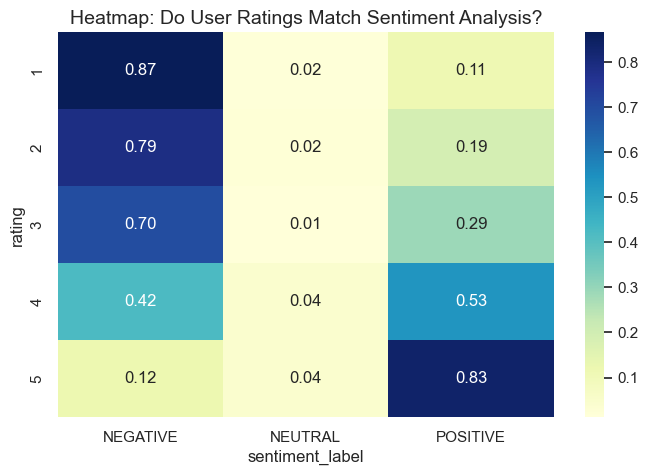

In [7]:
# Correlation Heatmap: Sentiment vs Rating
plt.figure(figsize=(8, 5))
cross_tab = pd.crosstab(df['rating'], df['sentiment_label'], normalize='index')
sns.heatmap(cross_tab, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Heatmap: Do User Ratings Match Sentiment Analysis?', fontsize=14)
plt.show()

## 6. Structural Risk Assessment: Theme vs. Sentiment

This visualization tracks how the quality of service has evolved.

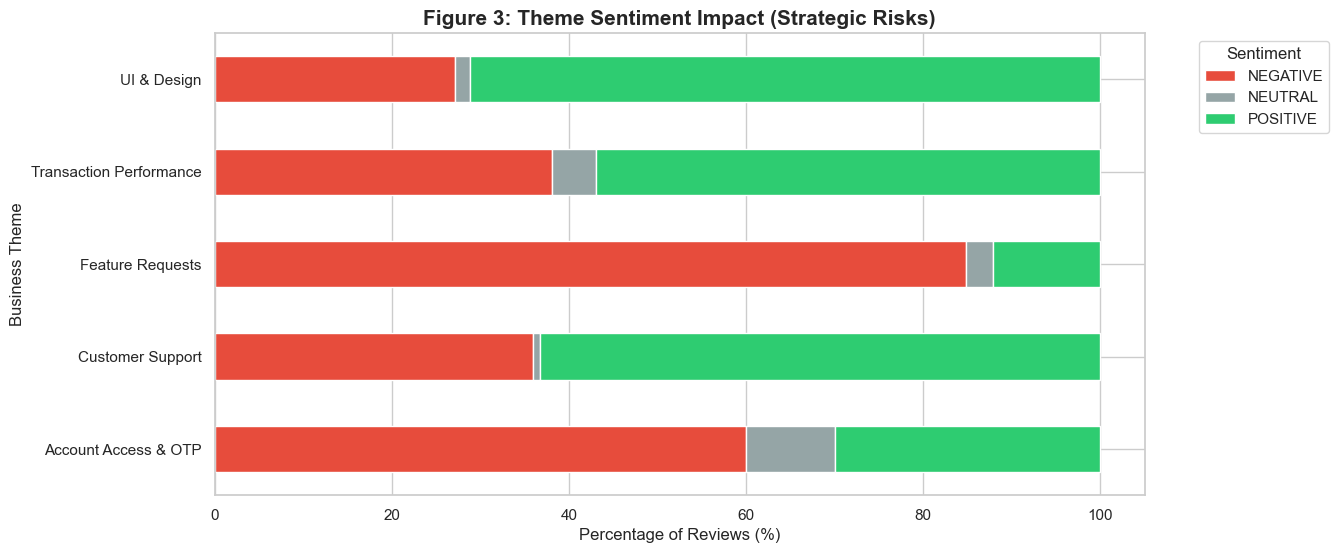

In [11]:
# Visual 3: Theme Sentiment Impact (Structural Risks)
theme_sent = df.groupby(['identified_theme', 'sentiment_label']).size().unstack().fillna(0)
theme_sent_pct = theme_sent.div(theme_sent.sum(axis=1), axis=0) * 100

theme_sent_pct.plot(kind='barh', stacked=True, color=['#e74c3c', '#95a5a6', '#2ecc71'])
plt.title('Figure 3: Theme Sentiment Impact (Strategic Risks)', fontsize=15, fontweight='bold')
plt.xlabel('Percentage of Reviews (%)')
plt.ylabel('Business Theme')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [9]:
# Data Integrity Proof
print("Final Data Integrity Check:")
print(df[['bank', 'sentiment_label', 'identified_theme']].isnull().sum())
print("\nBank Record Counts:")
print(df['bank'].value_counts())

Final Data Integrity Check:
bank                0
sentiment_label     0
identified_theme    0
dtype: int64

Bank Record Counts:
bank
Commercial Bank of Ethiopia    500
Bank of Abyssinia              500
Dashen Bank                    500
Name: count, dtype: int64


##  8. Structural Risk Assessment: Theme vs. Sentiment

This visualization highlights where the app is failing. For instance, if the "Transaction Performance" bar has a large red segment, it indicates a structural infrastructure issue. This allows for targeted engineering interventions

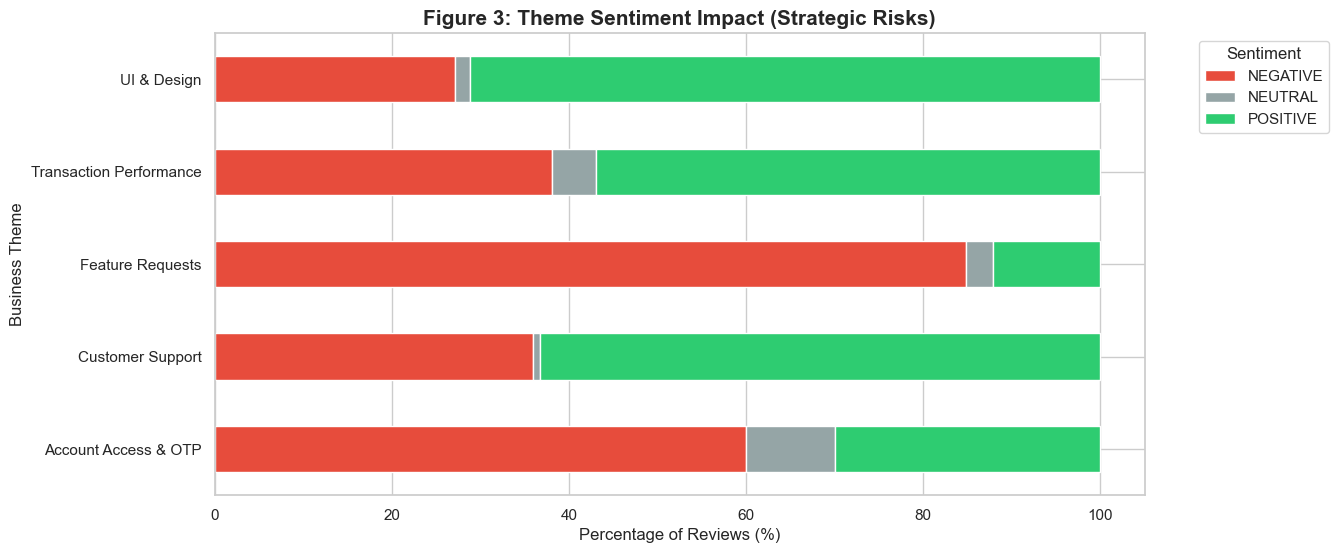

In [12]:
# Visual 3: Theme Sentiment Impact (Structural Risks)
theme_sent = df.groupby(['identified_theme', 'sentiment_label']).size().unstack().fillna(0)
theme_sent_pct = theme_sent.div(theme_sent.sum(axis=1), axis=0) * 100

theme_sent_pct.plot(kind='barh', stacked=True, color=['#e74c3c', '#95a5a6', '#2ecc71'])
plt.title('Figure 3: Theme Sentiment Impact (Strategic Risks)', fontsize=15, fontweight='bold')
plt.xlabel('Percentage of Reviews (%)')
plt.ylabel('Business Theme')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 9.  The Voice of the Customer: Strategic Keyword Impact

Using TF-IDF (Term Frequency-Inverse Document Frequency), we extract the words that actually matter. Unlike simple word counts, this highlights unique technical blockers. Mentions of "OTP" or "Transfer" in this chart prove that the user frustration is grounded in specific functional failures.

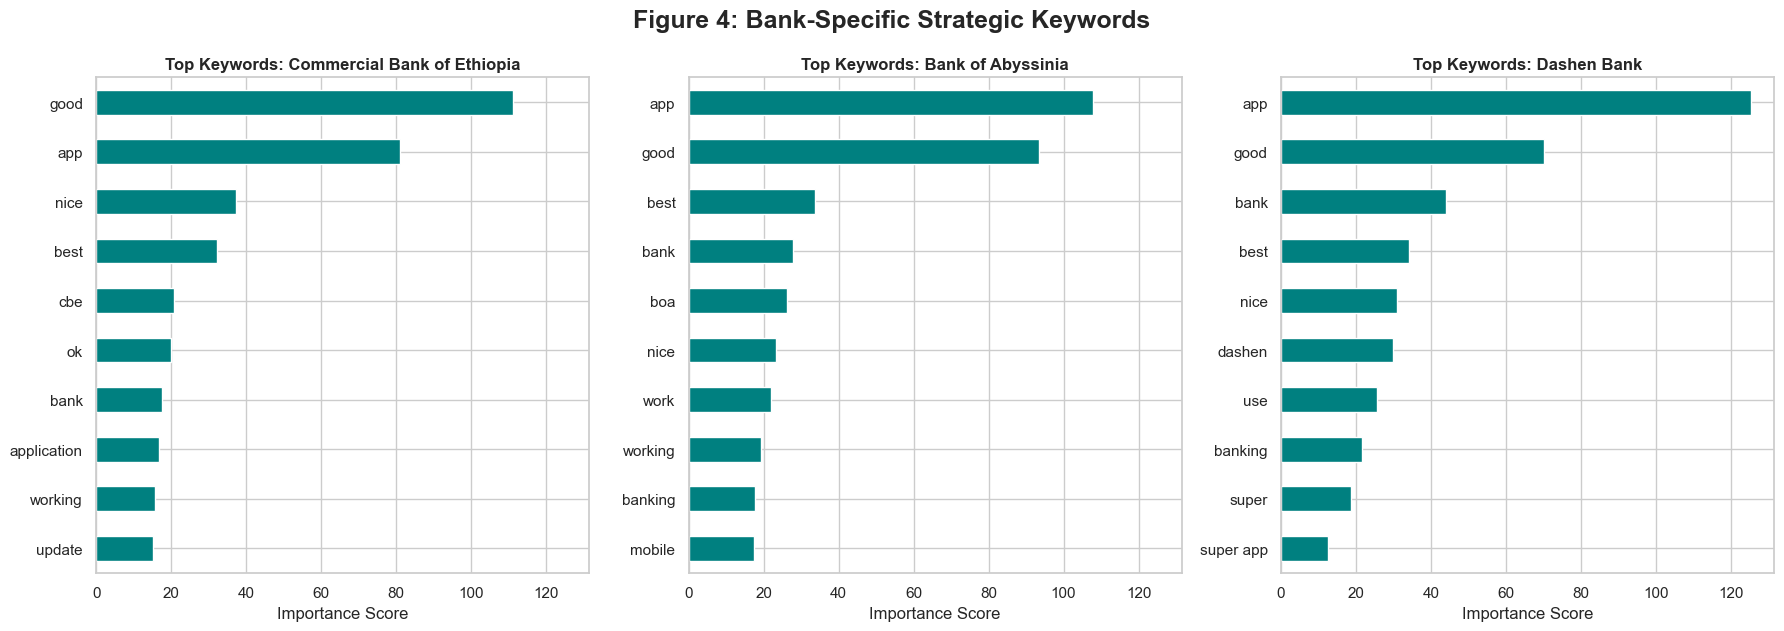

In [14]:
# Visual 4: Customer Vocabulary (Faceted TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)
banks = df['bank'].unique()

for i, bank in enumerate(banks):
    # Filter text for this specific bank
    bank_text = df[df['bank'] == bank]['review_text'].astype(str)
    
    # Calculate TF-IDF
    vec = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=10)
    weights = vec.fit_transform(bank_text)
    keywords = pd.DataFrame(weights.toarray(), columns=vec.get_feature_names_out()).sum().sort_values(ascending=True)
    
    # Plot to subplot
    keywords.plot(kind='barh', ax=axes[i], color='teal')
    axes[i].set_title(f'Top Keywords: {bank}', fontweight='bold')
    axes[i].set_xlabel('Importance Score')

plt.tight_layout()
plt.suptitle('Figure 4: Bank-Specific Strategic Keywords', fontsize=18, fontweight='bold', y=1.05)
plt.show()

## 10. Customer Word Clouds
This visualization represents the "Visual Vocabulary" of the user base. The size of each word indicates its frequency in the reviews.

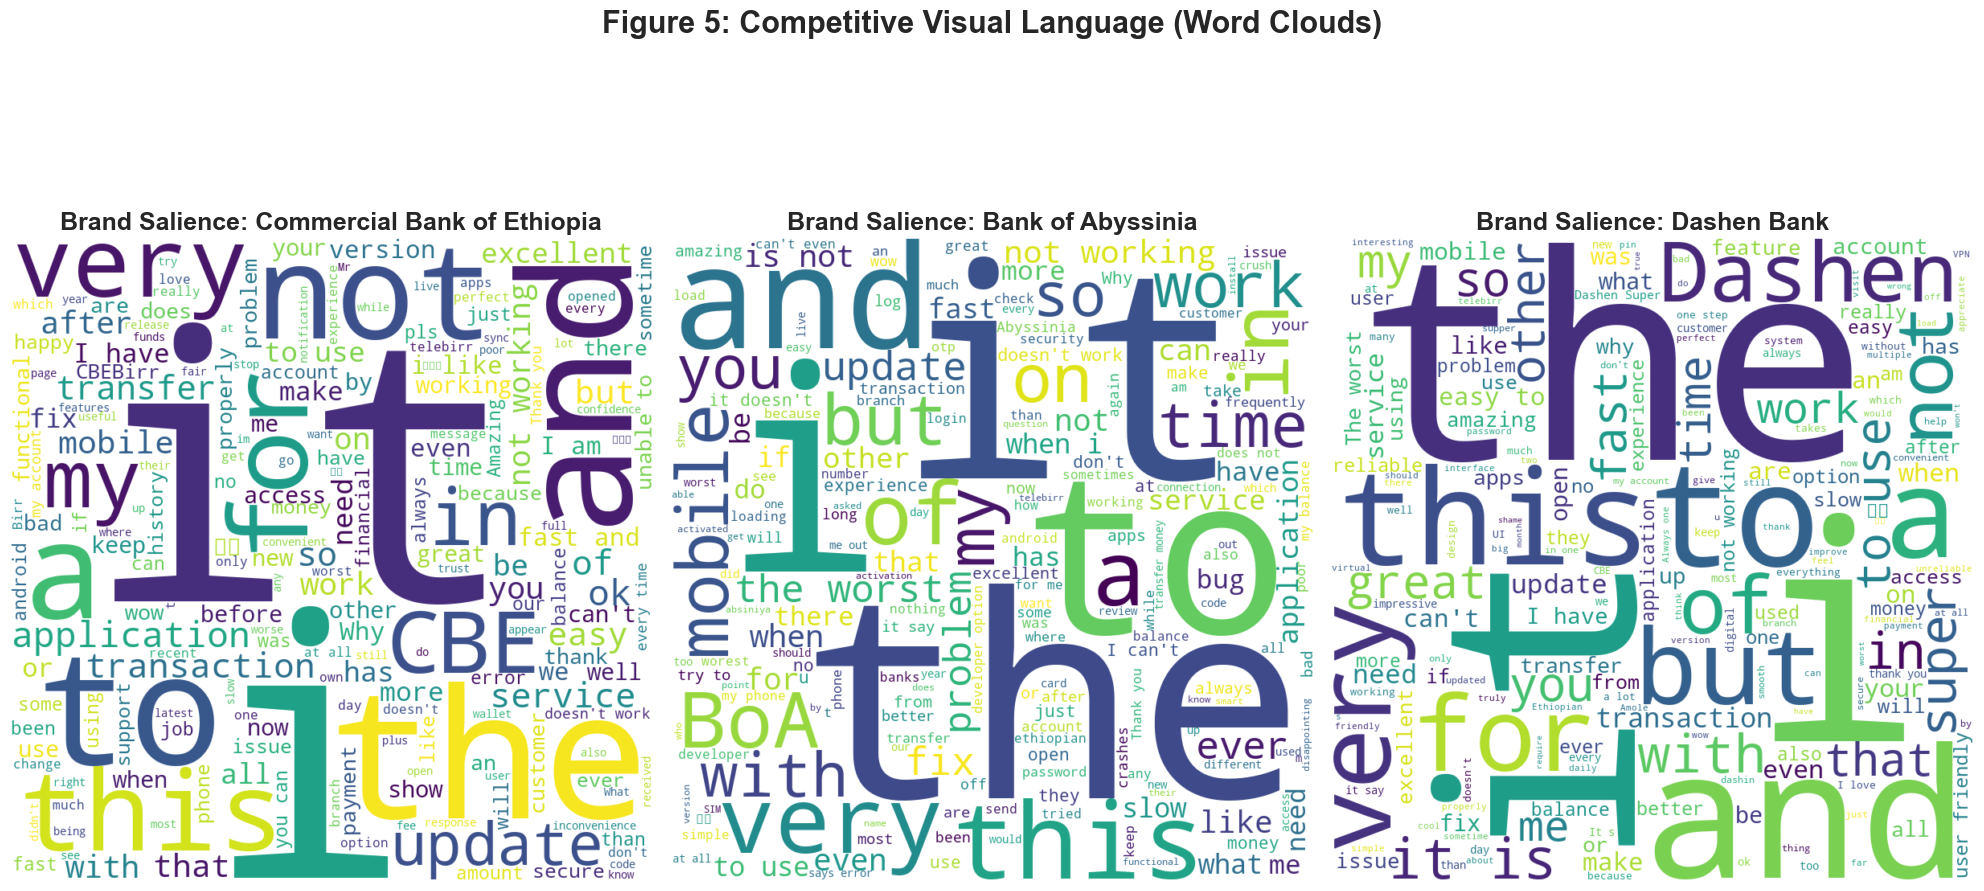

In [16]:
# Visual 5: Side-by-Side Word Clouds per Bank
from wordcloud import WordCloud

# Setup the figure
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
banks = df['bank'].unique()

# Define common stop words to keep the clouds clean
custom_stopwords = ['app', 'bank', 'banking', 'ethiopia', 'good', 'best', 'nice', 'please']

for i, bank in enumerate(banks):
    # Combine all reviews for this bank into one large string
    text = " ".join(df[df['bank'] == bank]['review_text'].astype(str).tolist())
    
    # Generate WordCloud
    wordcloud = WordCloud(
        width=800, 
        height=800,
        background_color='white',
        colormap='viridis',
        stopwords=custom_stopwords,
        min_font_size=10
    ).generate(text)
    
    # Display
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'Brand Salience: {bank}', fontsize=18, fontweight='bold')
    axes[i].axis("off")

plt.tight_layout()
plt.suptitle('Figure 5: Competitive Visual Language (Word Clouds)', fontsize=22, fontweight='bold', y=1.05)
plt.show()

## 11,  Sentiment Velocity: Weekly Performance Trend
This chart tracks the "Health" of the app over time. We map sentiment to a numeric scale (Positive = 1, Neutral = 0, Negative = -1).

    Insight: A sudden drop in the line indicates a "Broken Update" or a "Server Outage."

    Strategic Value: It allows Omega Consultancy to correlate sentiment crashes with specific app version releases.

c:\Users\Betty\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
c:\Users\Betty\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
c:\Users\Betty\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


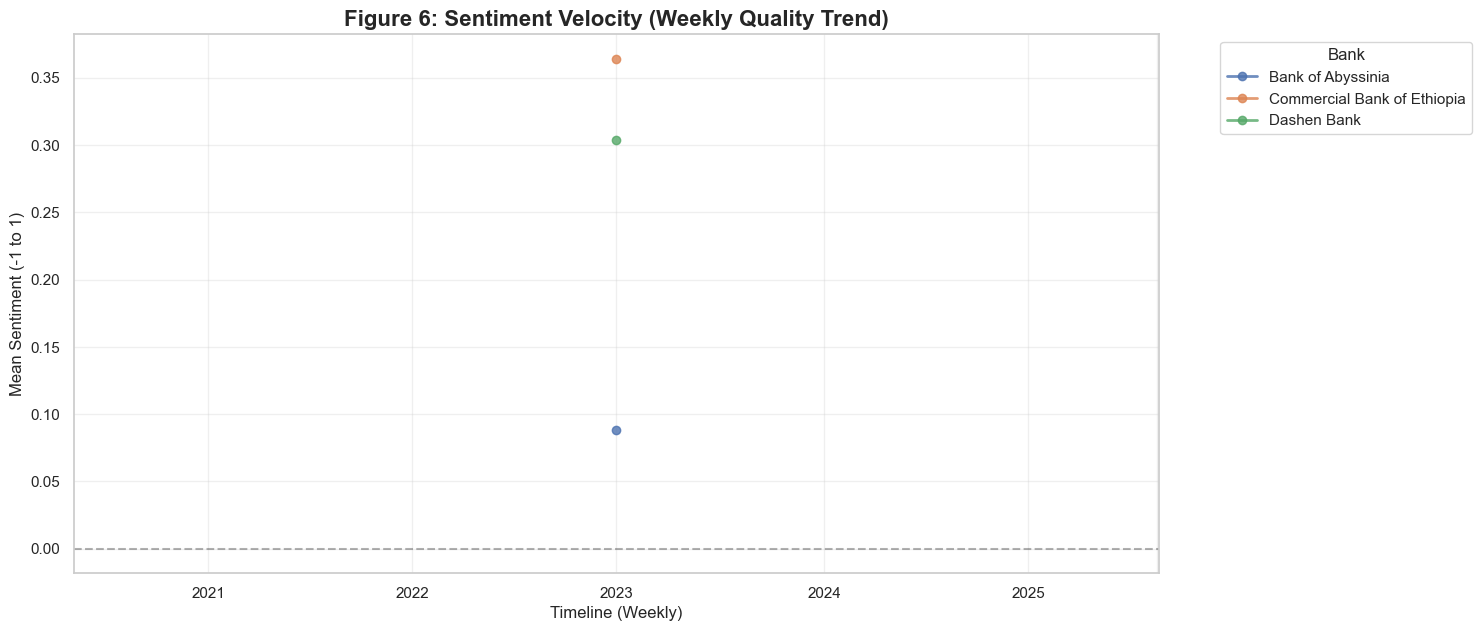

In [17]:
# Visual 6: Weekly Mean Sentiment Trend
plt.figure(figsize=(14, 7))

# Ensure date is datetime format
df['date'] = pd.to_datetime(df['date'])

# Map sentiment to numeric for calculation
sent_map = {'POSITIVE': 1, 'NEUTRAL': 0, 'NEGATIVE': -1}
df['sent_score'] = df['sentiment_label'].map(sent_map)

# Group by Week and Bank, then calculate mean
trend_df = df.groupby([pd.Grouper(key='date', freq='W'), 'bank'])['sent_score'].mean().unstack()

# Plot
trend_df.plot(marker='o', linewidth=2, alpha=0.8, ax=plt.gca())
plt.title('Figure 6: Sentiment Velocity (Weekly Quality Trend)', fontsize=16, fontweight='bold')
plt.ylabel('Mean Sentiment (-1 to 1)')
plt.xlabel('Timeline (Weekly)')
plt.axhline(0, color='black', linestyle='--', alpha=0.3) # Neutral baseline
plt.legend(title='Bank', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

## 12. System Usage Intensity: Review Volume Spikes
n the Ethiopian market, review volume is a proxy for app usage.

    Observation: Significant spikes often occur during the last week of the month (salary disbursement).

    Strategic Value: For CBE, if volume spikes align with sentiment drops, it proves that the infrastructure is failing under Peak Load. We call this "The Month-End Crisis" signal.

c:\Users\Betty\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
c:\Users\Betty\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
c:\Users\Betty\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


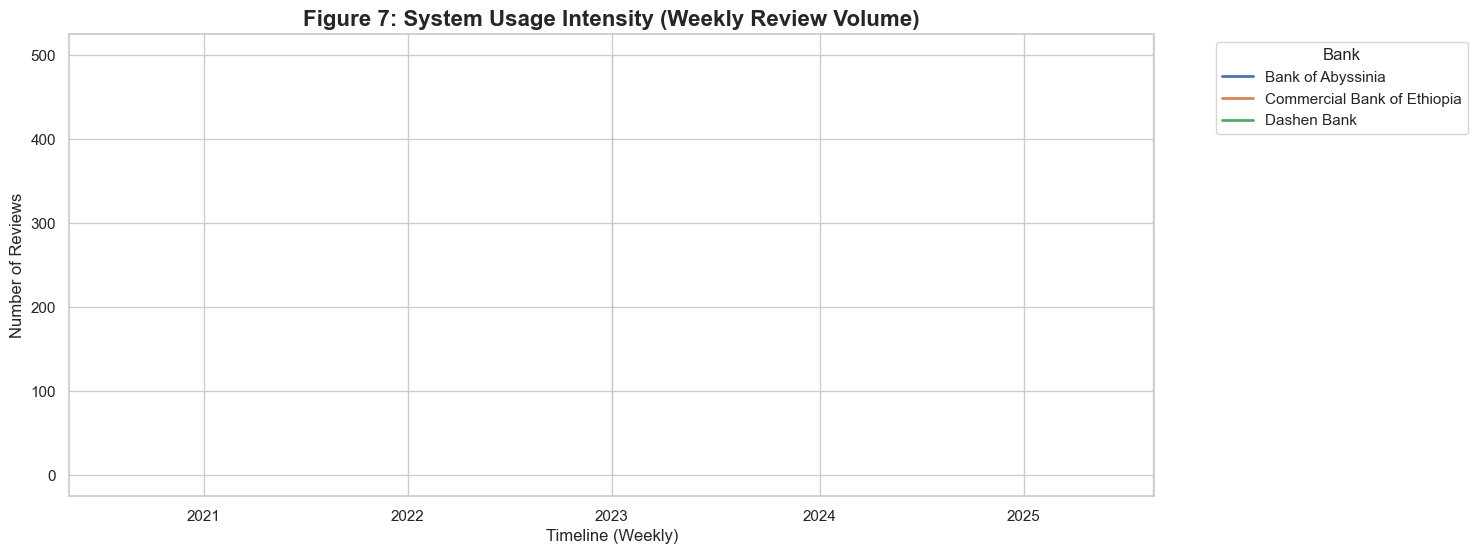

In [18]:
# Visual 7: Review Volume Trend (Peak Load Analysis)
plt.figure(figsize=(14, 6))

# Count reviews per week
vol_trend = df.groupby([pd.Grouper(key='date', freq='W'), 'bank']).size().unstack().fillna(0)

# Plot
vol_trend.plot(kind='line', linewidth=2, ax=plt.gca())
plt.title('Figure 7: System Usage Intensity (Weekly Review Volume)', fontsize=16, fontweight='bold')
plt.ylabel('Number of Reviews')
plt.xlabel('Timeline (Weekly)')
plt.legend(title='Bank', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.fill_between(vol_trend.index, vol_trend.max(axis=1), alpha=0.1, color='gray') # Highlight volume area
plt.show()